# TensorFlow/Keras classification model:

```
Input Layer: (defined by input_shape)
Hidden Layer 1: 2 neurons
Hidden Layer 2: 3 neurons
Output Layer: 1 neuron (Binary Classification)

Here the input has 4 features

        Input Layer
      x1  x2  x3  x4
          │
          │
   ┌──────────────┐
   │ Hidden Layer │
   │   2 Neurons  │
   └──────────────┘
          │
          │
   ┌──────────────┐
   │ Hidden Layer │
   │   3 Neurons  │
   └──────────────┘
          │
          │
      Output Layer
        1 Neuron
     (Sigmoid → 0/1)

In [59]:
import numpy as np

# The dataset is created with simple following rule:
# If two or more input values are 1, then the label is 1. Otherwise, the label is 0.

X_train = np.array([
    [0,0,0,0],
    [0,0,0,1],
    [0,0,1,0],
    [0,1,0,0],
    [1,0,0,0],
    [1,1,0,0],
    [1,1,1,0],
    [1,1,1,1],
    [0,1,1,1],
    [1,0,1,1]
], dtype=float)

# Binary labels
y_train = np.array([
    0,
    0,
    0,
    0,
    0,
    1,
    1,
    1,
    1,
    1
], dtype=float)

In [60]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create the model
# model = Sequential([
#     Dense(2, activation='relu', input_shape=(4,), name="Hidden_Layer_1"),
#     Dense(3, activation='relu', name="Hidden_Layer_2"),
#     Dense(1, activation='sigmoid', name="Output_Layer")
# ])

# 1. Initialize a blank model
model = Sequential()
model.add(Dense(units=2, activation='relu', input_shape=(4,), name="Hidden_1"))
model.add(Dense(units=3, activation='relu', name="Hidden_2"))
model.add(Dense(units=1, activation='sigmoid', name="Output"))


# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Hidden_1 (Dense)            (None, 2)                 10        
                                                                 
 Hidden_2 (Dense)            (None, 3)                 9         
                                                                 
 Output (Dense)              (None, 1)                 4         
                                                                 
Total params: 23 (92.00 Byte)
Trainable params: 23 (92.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


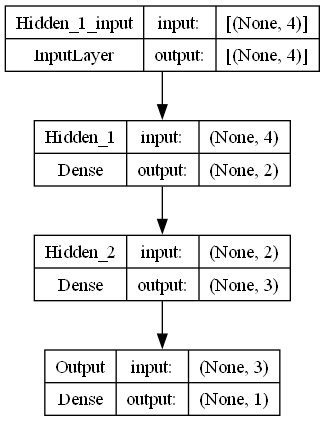

In [61]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='junk.png', show_shapes=True, show_layer_names=True)

In [62]:
# train the model
history = model.fit(
    X_train,
    y_train,
    epochs=700,
    verbose=0
)

print("Training Complete!")


Training Complete!


In [63]:
# Test Data


X_test = np.array([
    [1,1,0,1],
    [0,0,1,1],
    [1,0,0,0],
    [1,1,1,1]
], dtype=float)

# Actual answers
y_test = np.array([1,0,0,1])


# Step 6: Prediction


predictions = model.predict(X_test)

print("\nResults\n")

for i in range(len(X_test)):
    predicted_probability = predictions[i][0]
    predicted_class = 1 if predicted_probability >= 0.5 else 0

    print(f"Input            : {X_test[i]}")
    print(f"Actual Class     : {y_test[i]}")
    print(f"Predicted Prob.  : {predicted_probability:.4f}")
    print(f"Predicted Class  : {predicted_class}")
    print("-"*40)

# -----------------------------
# Step 7: Evaluate
# -----------------------------

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"\nTest Accuracy : {accuracy:.2f}")

1/1 [==============================] - 0s 87ms/step

Results

Input            : [1. 1. 0. 1.]
Actual Class     : 1
Predicted Prob.  : 0.9907
Predicted Class  : 1
----------------------------------------
Input            : [0. 0. 1. 1.]
Actual Class     : 0
Predicted Prob.  : 0.8815
Predicted Class  : 1
----------------------------------------
Input            : [1. 0. 0. 0.]
Actual Class     : 0
Predicted Prob.  : 0.3442
Predicted Class  : 0
----------------------------------------
Input            : [1. 1. 1. 1.]
Actual Class     : 1
Predicted Prob.  : 0.9993
Predicted Class  : 1
----------------------------------------

Test Accuracy : 0.75


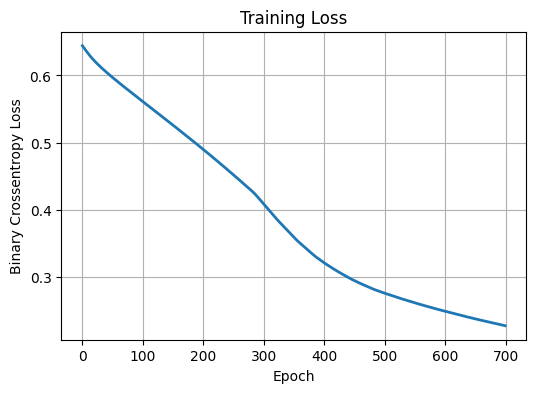

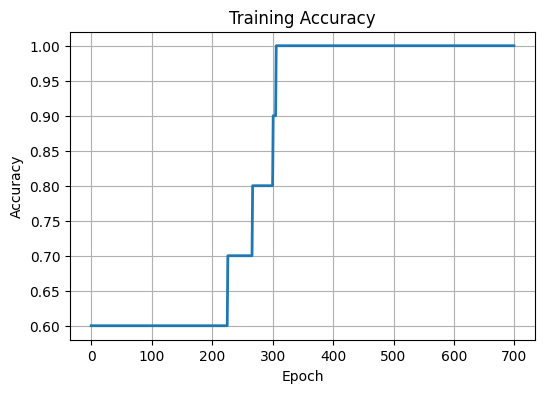

In [64]:
import matplotlib.pyplot as plt

# Plot Loss
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], linewidth=2)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.grid(True)
plt.show()

# Plot Accuracy
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], linewidth=2)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# TensorFlow/Keras regression model:

Create the target using a simple mathematical relationship.

For example,

$$y = 2x_1 + 3x_2 + x_3 + 4x_4$$


In [70]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#Training Dataset

X_train = np.array([
    [1,2,3,1],
    [2,1,1,2],
    [3,2,2,3],
    [4,2,3,4],
    [5,3,2,5],
    [6,3,4,6],
    [7,4,3,7],
    [8,4,5,8],
    [9,5,4,9],
    [10,5,5,10]
], dtype=float)

y_train = np.array([
    15,
    16,
    26,
    33,
    39,
    51,
    58,
    65,
    73,
    80
], dtype=float)

In [71]:
# Build Model

# model = Sequential([
#     Dense(2, activation='relu', input_shape=(4,), name="Hidden_Layer_1"),
#     Dense(3, activation='relu', name="Hidden_Layer_2"),
#     Dense(1, activation='linear', name="Output_Layer")
# ])

model = Sequential()
model.add(Dense(units=2, activation='relu', input_shape=(4,), name="Hidden_Layer_1"))
model.add(Dense(units=3, activation='relu', name="Hidden_Layer_2"))
model.add(Dense(units=1, activation='linear', name="Output_Layer"))


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='mean_squared_error',
    metrics=['mae']
)

model.summary()

Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Hidden_Layer_1 (Dense)      (None, 2)                 10        
                                                                 
 Hidden_Layer_2 (Dense)      (None, 3)                 9         
                                                                 
 Output_Layer (Dense)        (None, 1)                 4         
                                                                 
Total params: 23 (92.00 Byte)
Trainable params: 23 (92.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


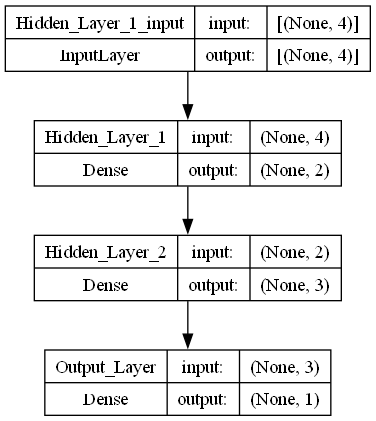

In [72]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='junk.png', show_shapes=True, show_layer_names=True)

In [73]:
# Train

history = model.fit(
    X_train,
    y_train,
    epochs=1000,
    verbose=0
)

print("Training Complete!")


Training Complete!


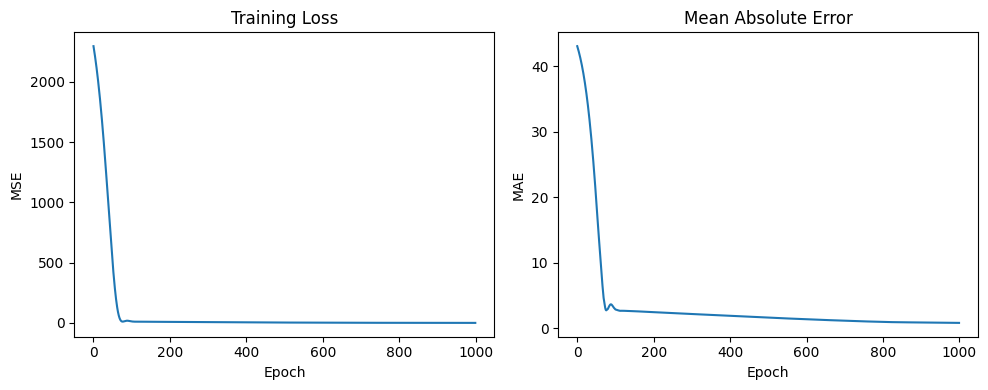


Prediction Results
------------------------------------------------------------
Features        : [1.5 2.  2.  1. ]
Actual Value    : 15.00
Predicted Value : 16.45
------------------------------------------------------------
Features        : [2.5 2.  3.  2. ]
Actual Value    : 22.00
Predicted Value : 24.21
------------------------------------------------------------
Features        : [4.5 3.  3.  4. ]
Actual Value    : 37.00
Predicted Value : 38.43
------------------------------------------------------------
Features        : [6.5 4.  4.  6. ]
Actual Value    : 53.00
Predicted Value : 54.57
------------------------------------------------------------
Features        : [8.5 5.  5.  8. ]
Actual Value    : 69.00
Predicted Value : 70.72
------------------------------------------------------------

Test MSE : 2.90
Test MAE : 1.68


In [74]:
# Step 4 : Plot History

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")

plt.subplot(1,2,2)
plt.plot(history.history['mae'])
plt.title("Mean Absolute Error")
plt.xlabel("Epoch")
plt.ylabel("MAE")

plt.tight_layout()
plt.show()


# Step 5 : Test Data


X_test = np.array([
    [1.5, 2,   2,   1],
    [2.5, 2,   3,   2],
    [4.5, 3,   3,   4],
    [6.5, 4,   4,   6],
    [8.5, 5,   5,   8]
], dtype=float)

# Actual prices
y_test = np.array([
    15,
    22,
    37,
    53,
    69
], dtype=float)


# Step 6 : Prediction
predictions = model.predict(X_test, verbose=0)

print("\nPrediction Results")
print("-"*60)

for features, actual, predicted in zip(X_test, y_test, predictions):
    print(f"Features        : {features}")
    print(f"Actual Value    : {actual:.2f}")
    print(f"Predicted Value : {predicted[0]:.2f}")
    print("-"*60)

loss, mae = model.evaluate(X_test, y_test, verbose=0)

print(f"\nTest MSE : {loss:.2f}")
print(f"Test MAE : {mae:.2f}")